In [1]:
import pandas as pd
import glob
import os
import scanpy as sc

In [2]:
from IPython.display import HTML, display
from cellphonedb.utils import db_releases_utils

display(HTML(db_releases_utils.get_remote_database_versions_html()['db_releases_html_table']))

In [3]:
sc.settings.figdir = "supp"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(20,20))


In [5]:
os.getcwd()

'/nfs/users/nfs_l/ls34/CCC_Analyses'

In [6]:
cpdb_version = 'v5.0.0'

# -- Path where the input files to generate the database are located
cpdb_target_dir = os.path.join('/nfs/team298/ls34/wound/cellphonedb/', cpdb_version)

In [7]:
from cellphonedb.utils import db_utils

db_utils.download_database(cpdb_target_dir, cpdb_version)

Downloaded cellphonedb.zip into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded complex_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded gene_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded interaction_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded protein_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded uniprot_synonyms.tsv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0/sources
Downloaded transcription_factor_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0/sources


In [9]:
cpdb_input_dir = '/nfs/team298/ls34/wound/cellphonedb/v5.0.0/'


In [10]:
from cellphonedb.utils import db_utils

# -- Creates new database
db_utils.create_db(cpdb_input_dir)


Created /nfs/team298/ls34/wound/cellphonedb/v5.0.0/cellphonedb_10_03_2025_164440.zip successfully


In [11]:
# %%bash

# mv /nfs/team298/ls34/cellphonedb/v5.0.0/cellphonedb_09_28_2024_123936.zip /nfs/team298/ls34/cellphonedb/v5.0.0/cellphonedb.zip

In [12]:
pd.set_option('display.max_columns', 100)

In [1]:
#os.listdir(cpdb_target_dir)

In [14]:
cpdb_file_path = os.path.join(cpdb_target_dir, 'cellphonedb.zip')
cpdb_file_path




'/nfs/team298/ls34/wound/cellphonedb/v5.0.0/cellphonedb.zip'

In [15]:
meta_file_path ='/nfs/team298/ls34/adult_skin/cellphonedb/input_files/metadata_all_TRM.tsv'

In [16]:
out_path = '/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore'


In [17]:
metadata = pd.read_csv(meta_file_path, sep = '\t')
metadata.head(3)

,barcode_sample,cell_type
0,AAAGATGAGCTAGGCA_E2,ILC3
1,AAAGATGTCCCATTTA_E2,TRM_IL13+
2,AAAGCAAGTCTCTCTG_E2,TRM_IL13+


In [18]:
metadata.cell_type.value_counts()

cell_type
TRM_IL13+           11036
ILC3                  908
ILC1                  691
ILC2                  515
ILC3_CCL1+PTGDS+      427
TRM_IL17+             248
ILC_Prolif            164
Name: count, dtype: int64

In [19]:
import anndata
#counts_file_path = '/nfs/team298/ls34/new_disease_atlas/model_scanvi5_v3skin_ADPSonly_clean_5941/ccc/normalised_log_counts_all_sebo.h5ad'
counts_file_path='/nfs/team298/ls34/adult_skin/cellphonedb/input_files/normalised_log_counts_all_TRM.h5ad'
adata = anndata.read_h5ad(counts_file_path)
adata.shape

(13989, 32732)

In [20]:
list(adata.obs.index).sort() == list(metadata['barcode_sample']).sort()


True

In [21]:
# KEEP_LIST = [#'Melanocyte',
#  #'KC3',
#  #'Sweat gland',
#  'Pericyte1_CCL19+_signalling',
#  'VE3_SELPhi',
#  'LE',
#  #'Sweat gland channel inner',
#  'VE1_ADAMTS6hi',
#  'F3: CCL19+',
#  'cDC1',
#  'Pericyte2_CASQ2_Muscle',
#  #'Sweat gland channel outer',
#  'nmSchwann',
#  'Mac2',
#  'F2/3: Bridge',
#  'F1: Superficial',
#  'LC',
#  'F2: Universal',
#  'F5: NGFR+',
#  'cDC2: IL1B+',
# # 'F4: TNN+COCH+',
#  'F1: Superficial regenerative',
#  #'Cartilage',
#  'cDC2: MMP12+',
#  #'KC_HF/SC: LGR6+ACTA2+',
#  'F5: RAMP1+',
#  'MigDC',
# # 'F4: DS_DPEP1+',
#  #'mSchwann',
#  #'KC1',
#  'ILC1_3',
#  'Plasma cell',
#  'MoDC',
#  'F6: Myofibroblast inflammatory',
#  #'pDC',
#  'Tc_IFNGhi',
#  #'Smooth muscle',
#  #'Bcell',
#  'Tc_IL13',
#  #'F4: DP_HHIP+',
#  'Treg',
#  'ILC2_inflammatory',
#  'Th',
#  'Tc',
# # 'KC_Sebocyte_basal',
# # 'KC_Sebocyte_inner',
#  'VE2',
#  #'Mono',
#  #'MacTREM2_CX3CR1+',
#  'NK',
#  'ILC1_NK',
#  'Tc_gamma_delta',
#  'Tr1',
#  'Mast cell',
#  'Tnaive/Tcm',
#  #'KC4',
#  #'KC2/3_cycling',
#  #'KC2',
#  #'KCinflamm_basal',
#  #'KCinflamm_int',
#  #'KC5',
#  'ILC2',
#  #'KC_HF: ORS/CL',
#  #'KC_HF: Basal_LGR5+',
#  #'F_Fascia',
#  #'Merkel cell',
#  #'KC_HF: Basal_NPNT+',
#  #'Mono CD16+',
#  #'KC_HF: IRS+HS',
#  'Mac1',
#  #'KCinflamm_late',
#  #'KCinflamm_cycling',
#  'Tc_IL17',
#  #'Satellite muscle',
#  #'Adipocyte',
#  #'Neutrophil',
#  #'Skeletal muscle'
# ]
# KEEP_LIST

In [22]:
0

0

In [23]:
from cellphonedb.src.core.methods import cpdb_statistical_analysis_method

cpdb_results = cpdb_statistical_analysis_method.call(
    cpdb_file_path = cpdb_file_path,                 # mandatory: CellphoneDB database zip file.
    meta_file_path = meta_file_path,                 # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = counts_file_path,             # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    counts_data = 'hgnc_symbol',                     # defines the gene annotation in counts matrix.
    #active_tfs_file_path = active_tf_path,           # optional: defines cell types and their active TFs.
    #microenvs_file_path = microenvs_file_path,       # optional (default: None): defines cells per microenvironment.
    score_interactions = True,                       # optional: whether to score interactions or not. 
    iterations = 1000,                               # denotes the number of shufflings performed in the analysis.
    threshold = 0.1,                                 # defines the min % of cells expressing a gene for this to be employed in the analysis.
    threads = 5,                                     # number of threads to use in the analysis.
    debug_seed = 42,                                 # debug randome seed. To disable >=0.
    result_precision = 3,                            # Sets the rounding for the mean values in significan_means.
    pvalue = 0.05,                                   # P-value threshold to employ for significance.
    subsampling = False,                             # To enable subsampling the data (geometri sketching).
    subsampling_log = False,                         # (mandatory) enable subsampling log1p for non log-transformed data inputs.
    subsampling_num_pc = 100,                        # Number of componets to subsample via geometric skectching (dafault: 100).
    subsampling_num_cells = 1000,                    # Number of cells to subsample (integer) (default: 1/3 of the dataset).
    separator = '|',                                 # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    debug = False,                                   # Saves all intermediate tables employed during the analysis in pkl format.
    output_path = out_path,                          # Path to save results.
    output_suffix = None                             # Replaces the timestamp in the output files by a user defined string in the  (default: None).
    )

Reading user files...
The following user files were loaded successfully:
/nfs/team298/ls34/adult_skin/cellphonedb/input_files/normalised_log_counts_all_TRM.h5ad
/nfs/team298/ls34/adult_skin/cellphonedb/input_files/metadata_all_TRM.tsv
[ ][CORE][03/10/25-16:44:46][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:5 Precision:3
[ ][CORE][03/10/25-16:44:46][WARNING] Debug random seed enabled. Set to 42
[ ][CORE][03/10/25-16:44:48][INFO] Running Real Analysis
[ ][CORE][03/10/25-16:44:48][INFO] Running Statistical Analysis


100%|██████████| 1000/1000 [02:38<00:00,  6.32it/s]

[ ][CORE][03/10/25-16:47:26][INFO] Building Pvalues result


[ ][CORE][03/10/25-16:47:26][INFO] Building results
[ ][CORE][03/10/25-16:47:27][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 7/7 [00:00<00:00, 34.44it/s]

[ ][CORE][03/10/25-16:47:27][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 7/7 [00:00<00:00, 86.38it/s]


[ ][CORE][03/10/25-16:47:27][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████| 49/49 [00:12<00:00,  3.91it/s]


Saved deconvoluted to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_deconvoluted_10_03_2025_164740.txt
Saved deconvoluted_percents to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_deconvoluted_percents_10_03_2025_164740.txt
Saved means to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_means_10_03_2025_164740.txt
Saved pvalues to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_pvalues_10_03_2025_164740.txt
Saved significant_means to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_significant_means_10_03_2025_164740.txt
Saved interaction_scores to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_interaction_scores_10_03_2025_164740.txt


# analysis

In [24]:
import os
import anndata as ad
import pandas as pd
import ktplotspy as kpy
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import os
#os.listdir('/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/')

In [3]:
# adata.obs

In [27]:
# cpdb_results

In [28]:
try:
    decon=cpdb_results['deconvoluted']
    deconv=cpdb_results['deconvoluted']
    means = cpdb_results['means']
    pvals = cpdb_results['pvalues']
    interaction_scores=cpdb_results['interaction_scores']
    print("instantantiated")
except:
    print("not loaded")
    
    deconv = pd.read_csv("/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_deconvoluted_percents_04_21_2025_202321.txt",  sep="\t")
    #means = pd.read_csv('/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_means_04_21_2025_202321.txt', sep="\t")
    means = pd.read_csv('/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_significant_means_04_21_2025_202321.txt', sep="\t")
    pvals = pd.read_csv("/nfs/team298/ls34/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_pvalues_04_21_2025_202321.txt", sep="\t")
    interaction_scores=pd.read_csv("/nfs/team298/ls34/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_interaction_scores_04_21_2025_202321.txt", sep="\t")
    import anndata
    counts_file_path = '/nfs/team298/ls34/wound/cellphonedb/input_files/normalised_log_counts.h5ad'
    adata = anndata.read_h5ad(counts_file_path)
    adata.shape
    
 # statistical_analysis_deconvoluted_percents_10_09_2024_201259.txt
#5.2M -rw-r--r-- 1 ls34 team298  21M Oct  9 20:13 
#1.8M -rw-r--r-- 1 ls34 team298  19M Oct  9 20:13 
#768K -rw-r--r-- 1 ls34 team298 5.2M Oct  9 20:13 statistical_analysis_significant_means_10_09_2024_201259.txt
 

instantantiated


In [29]:
#  statistical_analysis_deconvoluted_04_21_2025_202321.txt
# 960K -rw-r--r-- 1 ls34 team298  4.2M Apr 21 20:23 .txt
#  33M -rw-r--r-- 1 ls34 team298  112M Apr 21 20:23 .txt
# 9.4M -rw-r--r-- 1 ls34 team298   95M Apr 21 20:23 .txt
# 3.5M -rw-r--r-- 1 ls34 team298   26M Apr 21 20:24 statistical_analysis_significant_means_04_21_2025_202321.txt
#  40K drwxr-sr-x 2 ls34 team298  5.7K Apr 21 20:24 .
#  12M -rw-r--r-- 1 ls34 team298   a95M Apr 21 20:25 statistical_analysis_interaction_scores_04_21_2025_202321.txt
# ls34@node-13-15:~$ 

In [4]:
# try:
#     kpy.plot_cpdb_heatmap(pvals = pvals,
#                       degs_analysis = False,
#                       figsize = (20,20),
#                       title = "Sum of significant interactions")
# except:
#     1

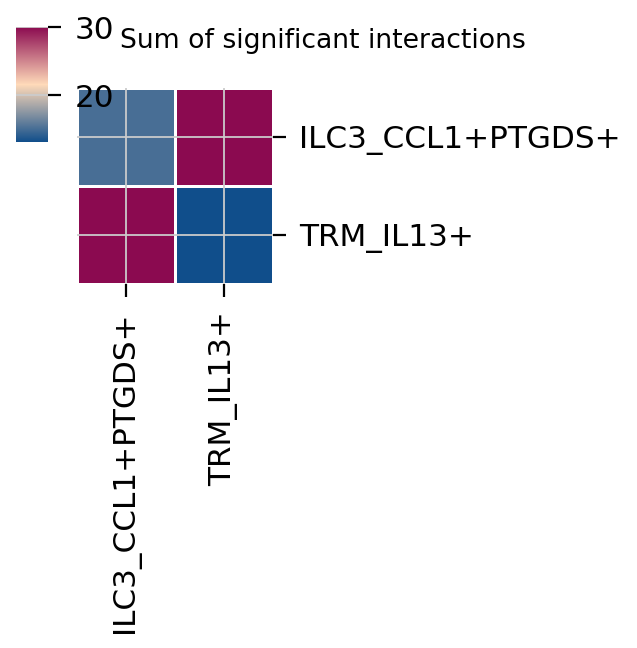

In [31]:
kpy.plot_cpdb_heatmap(
    pvals=pvals, cell_types=["TRM_IL13+", "ILC3_CCL1+PTGDS+",], figsize=(4, 4), title="Sum of significant interactions"
)

In [32]:
# kpy.plot_cpdb(
#     adata = adata,
#     cell_type1 = "PV MYH11|PV STEAP4|PV MMPP11",
#     cell_type2 = "EVT_1|EVT_2|GC|iEVT|eEVT|VCT_CCC",
#     means = cpdb_results['means'],
#     pvals = cpdb_results['pvalues'],
#     celltype_key = "cell_labels",
#     genes = ["TGFB2", "CSF1R"],
#     figsize = (10, 3),
#     title = "Interactions between\nPV and trophoblast",
#     max_size = 3,
#     highlight_size = 0.75,
#     degs_analysis = False,
#     standard_scale = True,
#     interaction_scores = cpdb_results['interaction_scores'],
#     scale_alpha_by_interaction_scores = True
# )

In [36]:
# from cellphonedb.utils import search_utils

# search_results = search_utils.search_analysis_results(
#     query_cell_types_1 =  "TRM_IL13+", # List of cells 1, will be paired to cells 2 (list or 'All').
#     query_cell_types_2 = "ILC3_CCL1+PTGDS+",
#     #['Sweat gland', "Sweat gland channel outer", "Sweat gland channel inner", "pDC", "F2/3: Perivascular",
#                          # "Pericyte1", "VE4_cap", "VE3_Prolif_APLN+", "pDC_LAMP5+"
#                              # List of cells 2, will be paired to cells 1 (list or 'All').
#   #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
#  #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
#     significant_means = means,          # significant_means file generated by CellphoneDB.
#     deconvoluted = deconv,                    # devonvoluted file generated by CellphoneDB.
#     interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
#     query_minimum_score = 0,                                       # minimum score that an interaction must have to be filtered.
#     separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
#     long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
#    # query_classifications = ['Signaling by Transforming growth factor']
# )

# search_results.head(50)

,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean


In [37]:
# from cellphonedb.utils import search_utils

# search_results = search_utils.search_analysis_results(
#     query_cell_types_1 = ['Bcell', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
#     query_cell_types_2 = "Sweat gland Myoepithelial",     # List of cells 2, will be paired to cells 1 (list or 'All').
#   #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
#  #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
#     significant_means = means,          # significant_means file generated by CellphoneDB.
#     deconvoluted = deconv,                    # devonvoluted file generated by CellphoneDB.
#     interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
#     query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
#     separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
#     long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
#    # query_classifications = ['Signaling by Transforming growth factor']
# )

# search_results = search_results[search_results["significant_mean"] > 0.0]

# search_results.tail(60)



,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean


In [38]:
# from cellphonedb.utils import search_utils

# search_results = search_utils.search_analysis_results(
#     query_cell_types_1 = ['MigDC', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
#     query_cell_types_2 = adata.obs["lvl5_annotation"].unique(),     # List of cells 2, will be paired to cells 1 (list or 'All').
#   #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
#  #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
#     significant_means = means,          # significant_means file generated by CellphoneDB.
#     deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
#     interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
#     query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
#     separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
#     long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
#    # query_classifications = ['Signaling by Transforming growth factor']
# )

# search_results = search_results[search_results["interacting_cells"].str.startswith("pDC")]
# search_results = search_results[search_results["significant_mean"] > 0.1]

# search_results.tail(60)



,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean


In [39]:
# from cellphonedb.utils import search_utils

# search_results = search_utils.search_analysis_results(
#     query_cell_types_1 = 'MigDC (cDC2)',  # List of cells 1, will be paired to cells 2 (list or 'All').
#     query_cell_types_2 = "TRM_IL13+",     # List of cells 2, will be paired to cells 1 (list or 'All').
#  # genes ="TNFRSF13C|TNFRSF13B|CCR6|CXCR5",# "CD27", "CD22", "COL19A1", #"ITGA10",
#      #"ITGB1", 
#     # "FCER2",# "FGFR2", 
#     # "COL19A1",#"CDH2",
#                                       # filter interactions based on the genes participating (list).
#   # query_interactions = ['TNFSF13B_TNFRSF13C'],                            # filter intereactions based on their name (list).
#     significant_means = means,          # significant_means file generated by CellphoneDB.
#     deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
#     interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
#     query_minimum_score = 10,                                       # minimum score that an interaction must have to be filtered.
#     separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
#     long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
#    # query_classifications = ['Signaling by Transforming growth factor']
# )

# #search_results = search_results[search_results["significant_mean"] > 0.0]

# search_results.head(60)



,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean


In [40]:
# from cellphonedb.utils import search_utils

# search_results = search_utils.search_analysis_results(
#     query_cell_types_1 = ['Bcell', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
#     query_cell_types_2 = adata.obs["lvl5_annotation"].unique(),     # List of cells 2, will be paired to cells 1 (list or 'All').
#  # genes ="TNFRSF13C|TNFRSF13B|CCR6|CXCR5",# "CD27", "CD22", "COL19A1", #"ITGA10",
#      #"ITGB1", 
#     # "FCER2",# "FGFR2", 
#     # "COL19A1",#"CDH2",
#                                       # filter interactions based on the genes participating (list).
#    query_interactions = ['TNFSF13B_TNFRSF13C'],                            # filter intereactions based on their name (list).
#     significant_means = means,          # significant_means file generated by CellphoneDB.
#     deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
#     interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
#     query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
#     separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
#     long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
#    # query_classifications = ['Signaling by Transforming growth factor']
# )

# search_results = search_results[search_results["significant_mean"] > 0.3]

# search_results.head(60)



,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean


In [41]:
search_results["interacting_pair"].unique()

array([], dtype=object)

In [42]:
['CD48_CD244', 'PTPRC_CD22', 'COL19A1_integrin_a2b1_complex',
       'FCER2_FGFR2', 'FCER2_integrin_aXb2_complex', 'CD70_CD27',
       'TNFSF13B_TNFRSF13B', 'TNFSF13B_TNFRSF13C', 'CXCL13_CXCR5'],

(['CD48_CD244',
  'PTPRC_CD22',
  'COL19A1_integrin_a2b1_complex',
  'FCER2_FGFR2',
  'FCER2_integrin_aXb2_complex',
  'CD70_CD27',
  'TNFSF13B_TNFRSF13B',
  'TNFSF13B_TNFRSF13C',
  'CXCL13_CXCR5'],)

In [43]:
import inspect

print(inspect.signature(kpy.plot_cpdb))

(adata: 'AnnData', cell_type1: str, cell_type2: str, means: pandas.core.frame.DataFrame, pvals: pandas.core.frame.DataFrame, celltype_key: str, interaction_scores: Optional[pandas.core.frame.DataFrame] = None, cellsign: Optional[pandas.core.frame.DataFrame] = None, degs_analysis: bool = False, splitby_key: Optional[str] = None, alpha: float = 0.05, keep_significant_only: bool = True, genes: Optional[str] = None, gene_family: Optional[Literal['chemokines', 'th1', 'th2', 'th17', 'treg', 'costimulatory', 'coinhibitory']] = None, custom_gene_family: Optional[Dict[str, List[str]]] = None, standard_scale: bool = True, cluster_rows: bool = True, cmap_name: str = 'viridis', max_size: int = 8, max_highlight_size: int = 3, default_style: bool = True, highlight_col: str = '#d62728', highlight_size: Optional[int] = None, special_character_regex_pattern: Optional[str] = None, exclude_interactions: Union[List, str, NoneType] = None, title: str = '', return_table: bool = False, figsize: Tuple[Union[i

In [ ]:
# 

In [44]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Bcell",
    cell_type2=KEEP,
    #   query_genes = ["CD200",'LY75', 'SLCO5A1', 'WNT5B', 'AD
   # AM12', "ACHE",
    #       "CD274", "PDCD1LG2", "IL12B", "TNFSF4", "PVR" ],
    genes=  ["CD48", "CD244", "CD70", "CD27", "CD22", "COL19A1", #"ITGA10",
     #"ITGB1", 
     "FCER2",# "FGFR2", 
     "COL19A1",#"CDH2",
     "CXCR5", ],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(12, 8),
)


# from cellphonedb.utils import search_utils

# search_results = search_utils.search_analysis_results(
#     query_cell_types_1 = adata.obs["lvl5_annotation"].unique(),  # List of cells 1, will be paired to cells 2 (list or 'All').
#     query_cell_types_2 = [ "MigDC"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#                                        # filter interactions based on the genes participating (list).
#  #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
#     significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
#     deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
#     interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
#     query_minimum_score = 0,                                       # minimum score that an interaction must have to be filtered.
#     separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
#     long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
#    # query_classifications = ['Signaling by Transforming growth factor']
# )

# search_results.head(50)



TypeError: '<' not supported between instances of 'str' and 'float'

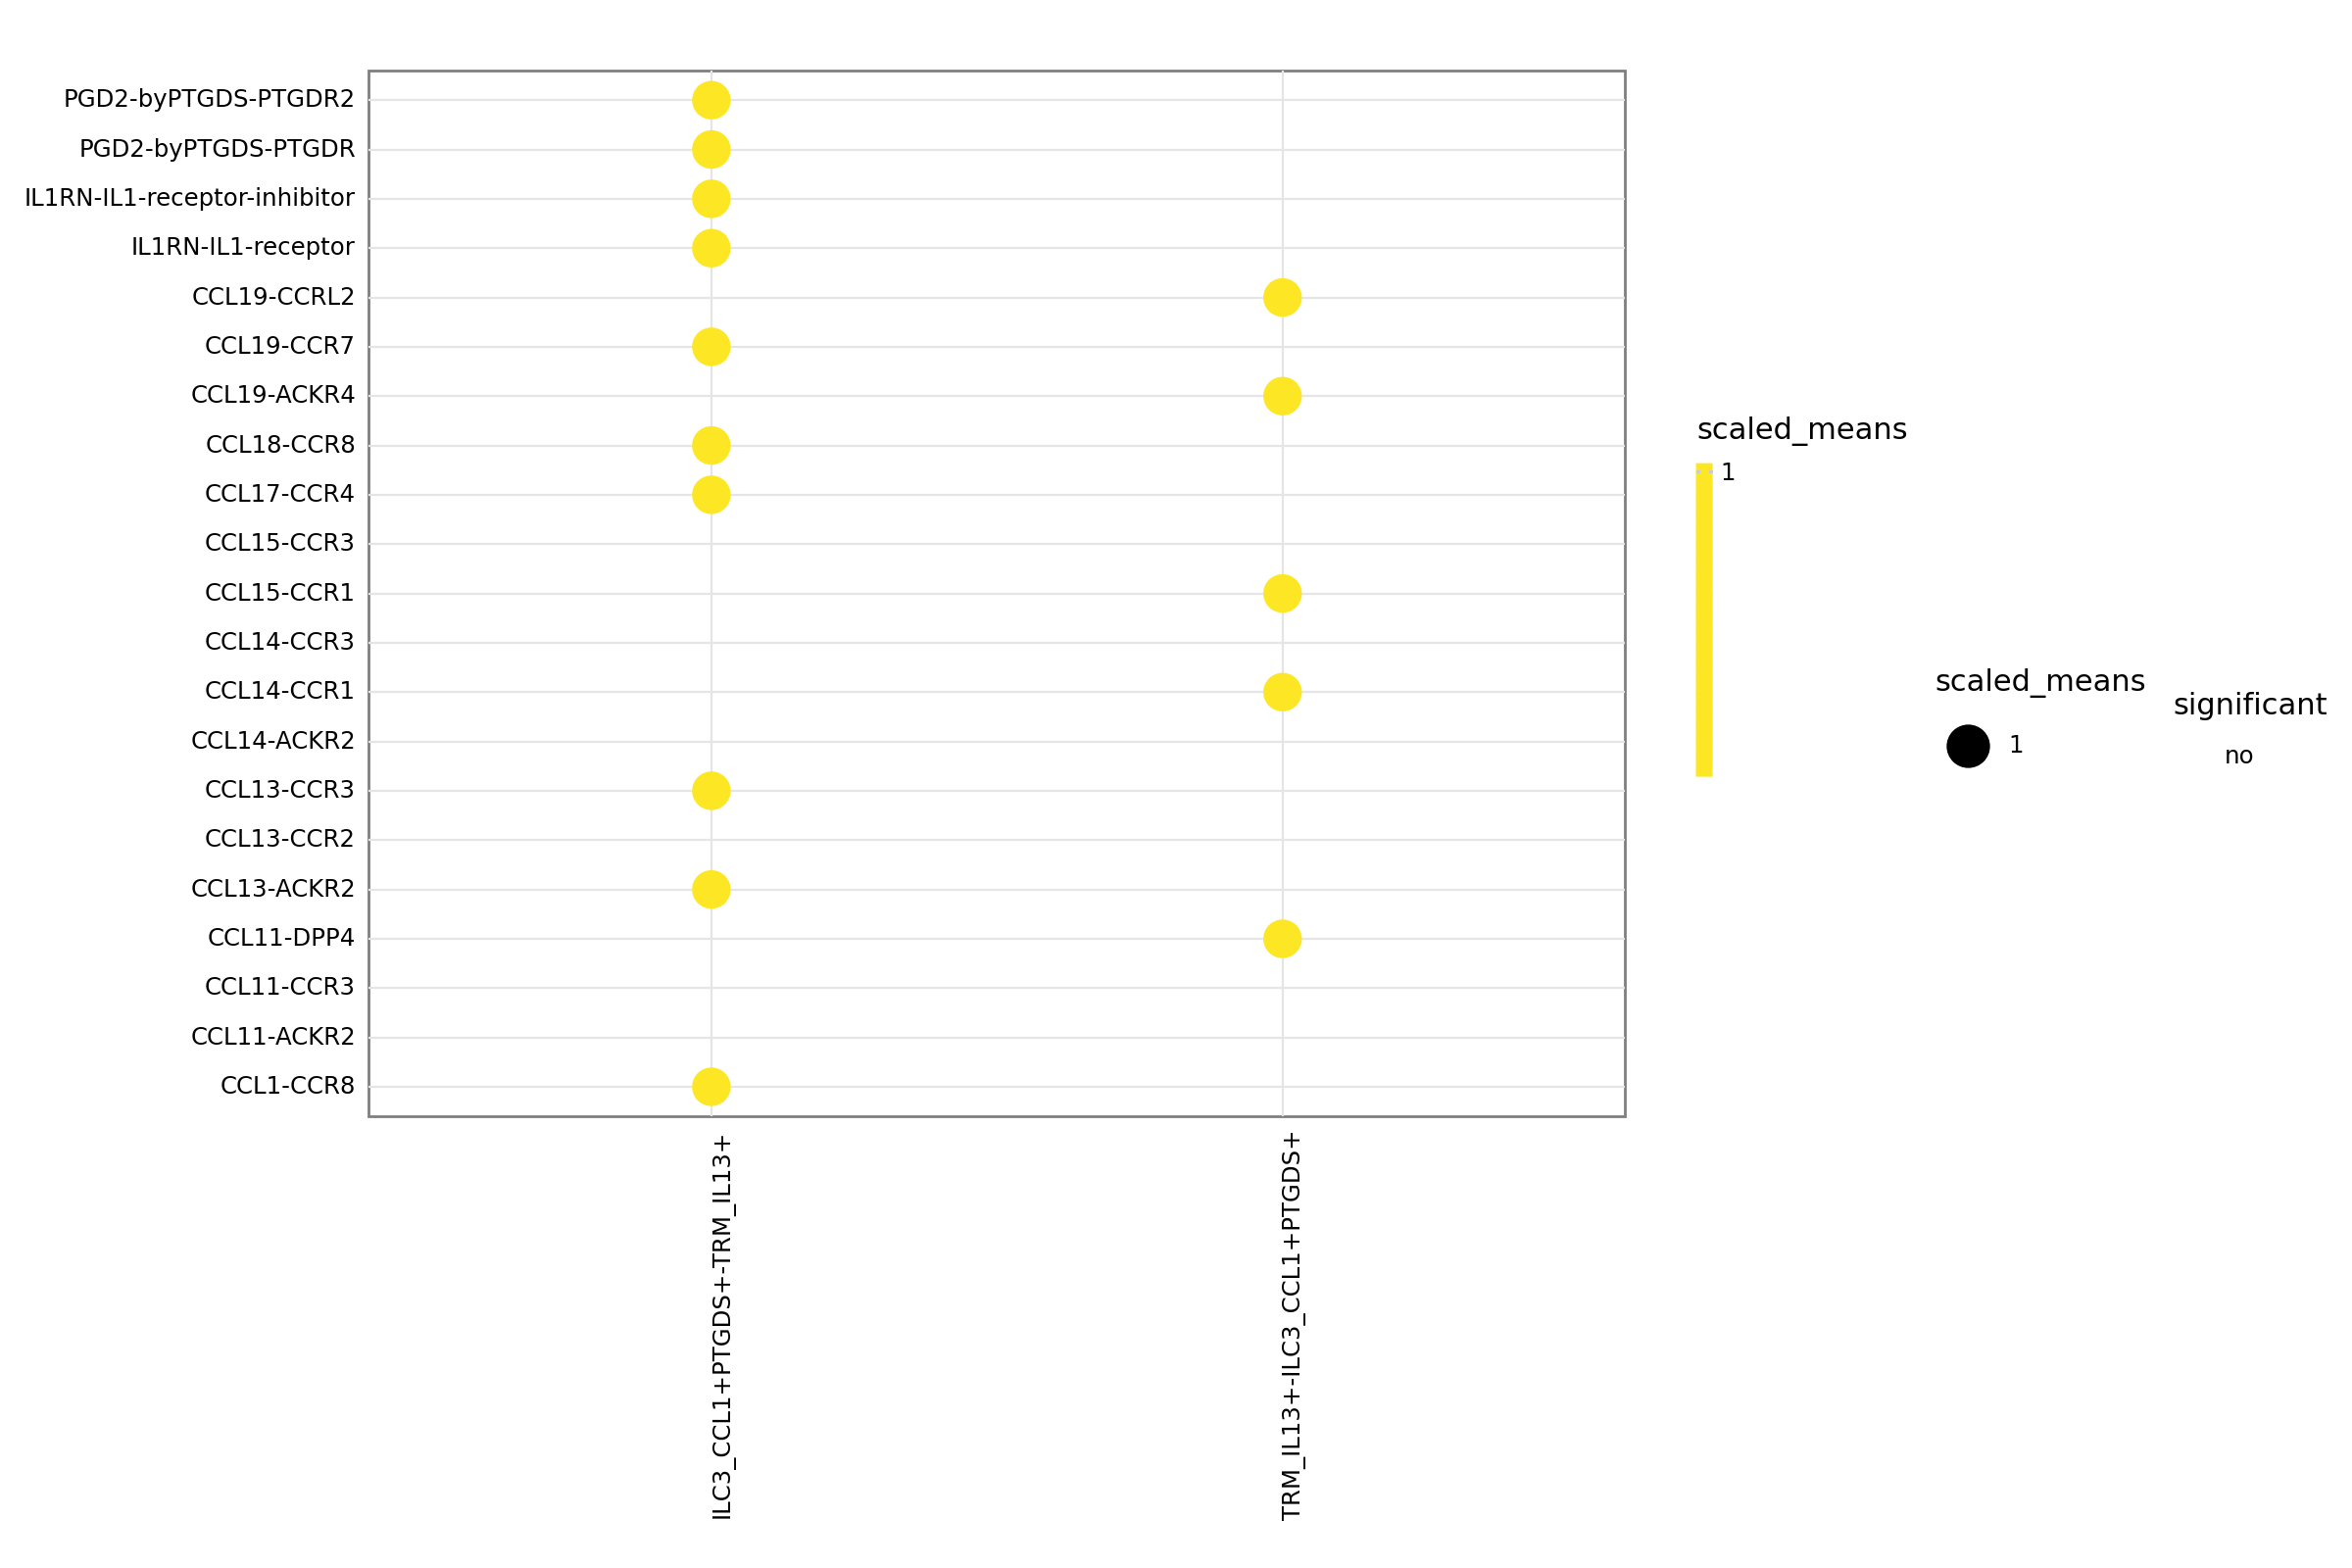

<Figure Size: (1200 x 800)>

In [51]:
# kpy.plot_cpdb(
#     adata=adata,
#     cell_type1="TRM_IL13+",
#     cell_type2="ILC3_CCL1+PTGDS+",
#     #   query_genes = ["CD200",'LY75', 'SLCO5A1', 'WNT5B', 'AD
#    # AM12', "ACHE",
#     #       "CD274", "PDCD1LG2", "IL12B", "TNFSF4", "PVR" ],
#   # genes=  ["CCL1"], # "TNFRSF13B", "CCR6",# "CD27", "CD22", "COL19A1", #"ITGA10",
#      #"ITGB1", 
#     # "FCER2",# "FGFR2", 
#     # "COL19A1",#"CDH2",
#    #  "CXCR5", ],
#     means=means,
#     pvals=pvals,
#     celltype_key="lvl5_annotation",
#     highlight_size=1,
#     figsize=(12, 8),
# )


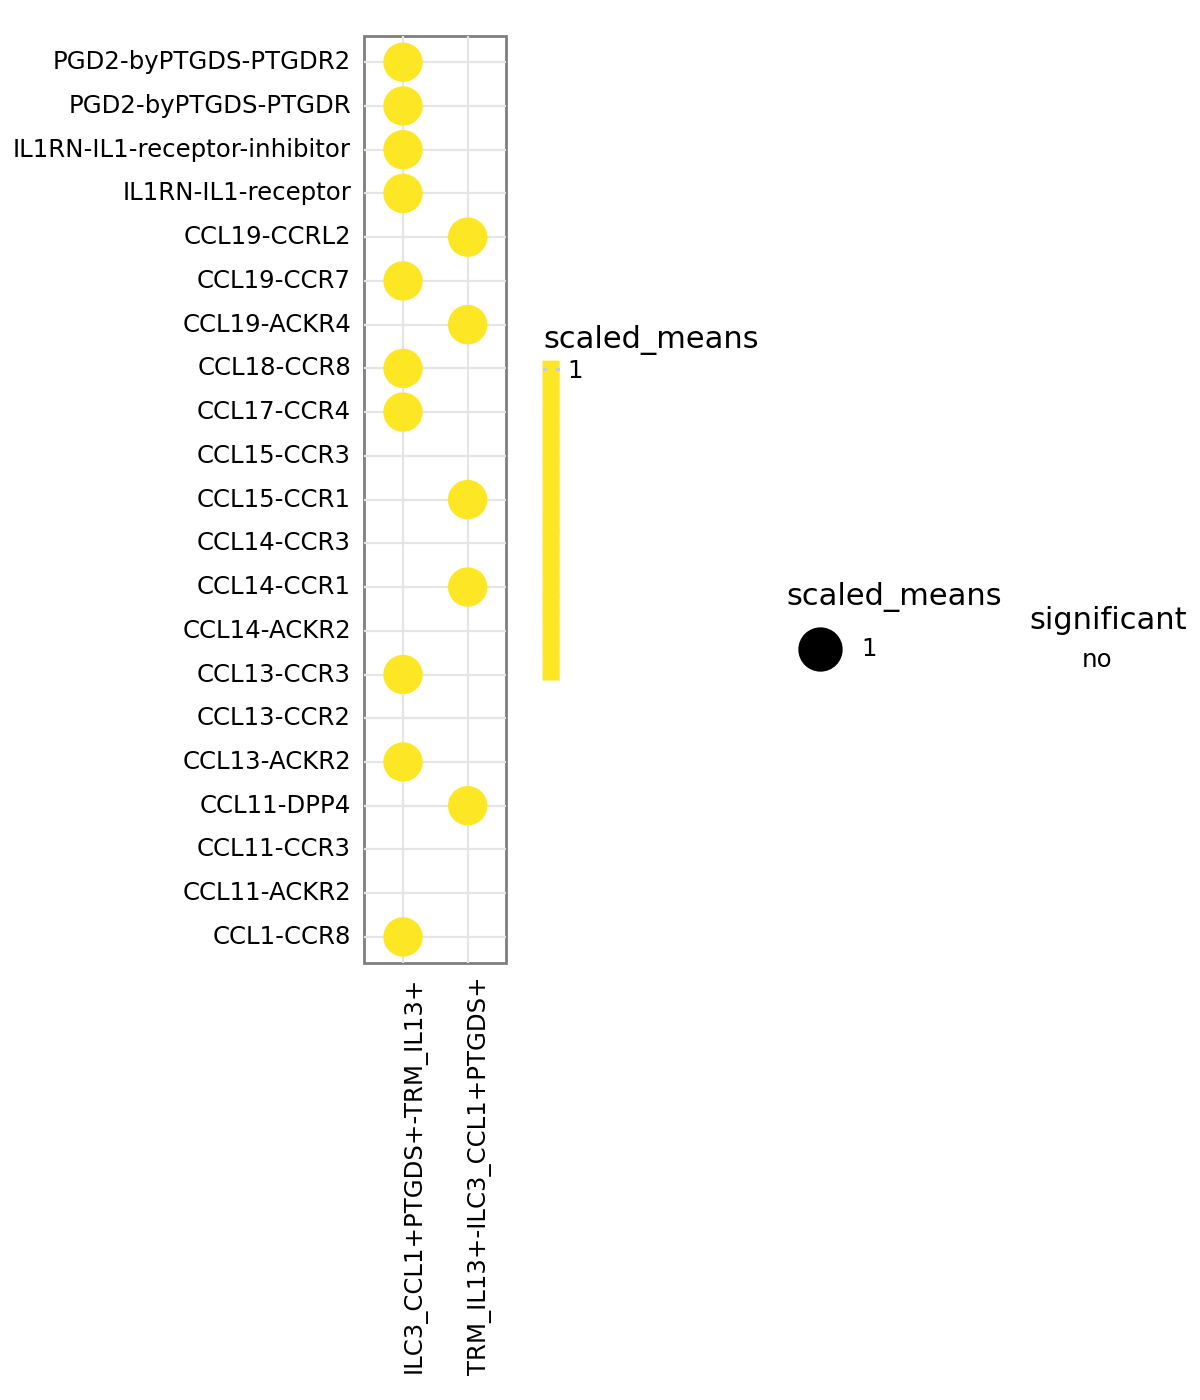

<Figure Size: (600 x 700)>

In [66]:
sc.settings.set_figure_params(dpi=300, dpi_save=300, facecolor="white", frameon=False, figsize=(20,20))

kpy.plot_cpdb(
    adata=adata,
    cell_type1="TRM_IL13+",
    cell_type2="ILC3_CCL1+PTGDS+",
       genes =[ 'PTGDS', 'PDLIM4', 'CCL1', 'IL1RN', 'PTGS1', 'PTP4A1'], # "TNFRSF13B", "CCR6",# "CD27", "CD22", "COL19A1", #"ITGA10",
     #"ITGB1", 
    # "FCER2",# "FGFR2", 
    # "COL19A1",#"CDH2",
   #  "CXCR5", ],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(6, 7),
       # save="ilc3_trm.pdf"

)
    

